In [ ]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


## 1. load the data

In [2]:
data = load_breast_cancer()
X = data.data
y = data.target


In [3]:
print("data shape", X.shape)
print("catogries", data.target_names)
print("Malignant (0):", (y == 0).sum(), "| Benign (1):", (y == 1).sum())

data shape (569, 30)
catogries ['malignant' 'benign']
Malignant (0): 212 | Benign (1): 357


## 2. Train-Test Split

I split the dataset into:
- **80% Training** — used to train the models
- **20% Testing** — used to evaluate the models

I use `stratify=y` to ensure both sets preserve the original class distribution,  
which is important since the dataset is slightly imbalanced.

In [4]:
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 455
Testing samples: 114



## 3. Model Training

I train three classification models using **default parameters**:

| Model | Note |
|-------|------|
| Logistic Regression | `max_iter=10000` to ensure convergence |
| SVM | Default parameters |
| KNN | Default parameters (k=5) |



In [5]:
# Logistic Regression
lr_model = LogisticRegression(random_state=42, max_iter=10000)
lr_model.fit(X_train, y_train)



,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [6]:
# Support Vector Machine
svm_model = SVC(random_state=42)
svm_model.fit(X_train, y_train)


,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [7]:
# K-Nearest Neighbors
knn_model = KNeighborsClassifier()
knn_model.fit(X_train, y_train)

print("All models trained successfully!")

All models trained successfully!



## 4. Model Evaluation

For each model, I compute the following metrics:

| Metric | Description |
|--------|-------------|
| **Accuracy** | Overall correct predictions |
| **Precision** | Of all predicted Benign, how many are actually Benign? |
| **Recall** | Of all actual Benign, how many did we correctly detect? |
| **F1-Score** | Balance between Precision and Recall |
| **Confusion Matrix** | Detailed breakdown of predictions |

> In a medical context, **Recall is the most critical metric** — missing a cancerous case is far more dangerous than a false alarm.

In [8]:
#Model Evaluation
models = {
    "Logistic Regression": lr_model,
    "SVM": svm_model,
    "KNN": knn_model
}

for name, model in models.items():
    y_pred = model.predict(X_test)
    
    print(f"********** {name} **********")
    print(f"Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
    print(f"Precision: {precision_score(y_test, y_pred):.4f}")
    print(f"Recall:    {recall_score(y_test, y_pred):.4f}")
    print(f"F1-Score:  {f1_score(y_test, y_pred):.4f}")
    print(f"Confusion Matrix:\n{confusion_matrix(y_test, y_pred)}")
    print()

********** Logistic Regression **********
Accuracy:  0.9649
Precision: 0.9595
Recall:    0.9861
F1-Score:  0.9726
Confusion Matrix:
[[39  3]
 [ 1 71]]

********** SVM **********
Accuracy:  0.9298
Precision: 0.9211
Recall:    0.9722
F1-Score:  0.9459
Confusion Matrix:
[[36  6]
 [ 2 70]]

********** KNN **********
Accuracy:  0.9123
Precision: 0.9429
Recall:    0.9167
F1-Score:  0.9296
Confusion Matrix:
[[38  4]
 [ 6 66]]



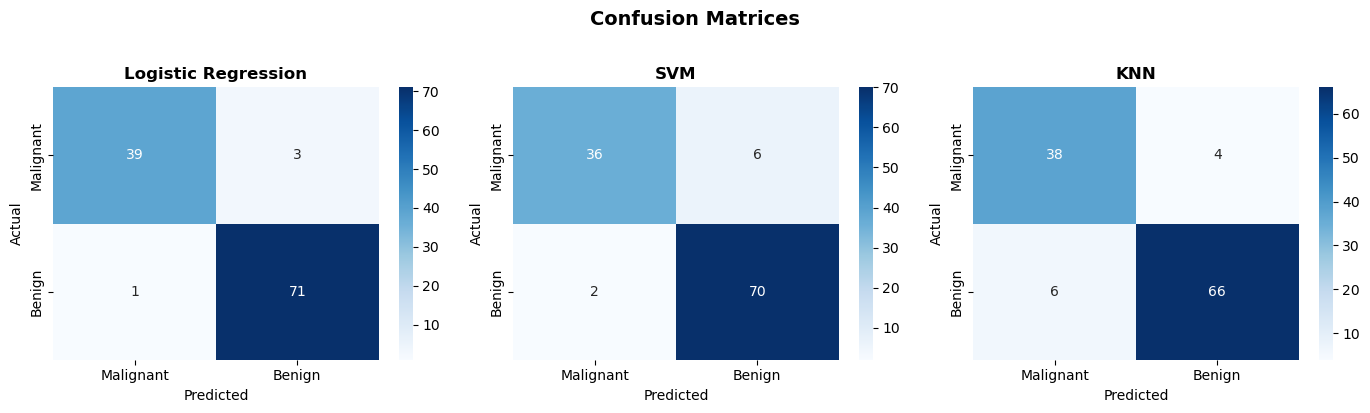

In [10]:
#Visualization
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, (name, model) in zip(axes, models.items()):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Malignant', 'Benign'],
                yticklabels=['Malignant', 'Benign'])
    ax.set_title(name, fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.suptitle('Confusion Matrices', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 5. Evaluation Results Summary

| Model | Accuracy | Precision | Recall | F1-Score |
|-------|----------|-----------|--------|----------|
| Logistic Regression | 0.9649 | 0.9595 | **0.9861** | **0.9726** |
| SVM | 0.9298 | 0.9211 | 0.9722 | 0.9459 |
| KNN | 0.9123 | 0.9429 | 0.9167 | 0.9296 |

#### Confusion Matrix Breakdown (Logistic Regression)
|  | Predicted Malignant | Predicted Benign |
|--|---------------------|-----------------|
| **Actual Malignant** | 39  | 3  |
| **Actual Benign** | 1  | 71  |

- **False Positives (3):** Predicted Benign but actually Malignant — dangerous in medical context
- **False Negatives (1):** Predicted Malignant but actually Benign



## 5. Model Comparison

In [ ]:
# Model Comparison Table

results = []

for name, model in models.items():
    y_pred = model.predict(X_test)
    results.append({
        "Model": name,
        "Accuracy":  round(accuracy_score(y_test, y_pred), 4),
        "Precision": round(precision_score(y_test, y_pred), 4),
        "Recall":    round(recall_score(y_test, y_pred), 4),
        "F1-Score":  round(f1_score(y_test, y_pred), 4)
    })

df_results = pd.DataFrame(results)
df_results = df_results.sort_values("F1-Score", ascending=False).reset_index(drop=True)
print(df_results.to_string(index=False))

              Model  Accuracy  Precision  Recall  F1-Score
Logistic Regression    0.9649     0.9595  0.9861    0.9726
                SVM    0.9298     0.9211  0.9722    0.9459
                KNN    0.9123     0.9429  0.9167    0.9296




## Conclusion

### Which model performed best?
**Logistic Regression** achieved the best performance across all metrics:
- Highest Accuracy: **96.49%**
- Highest Recall: **98.61%**
- Highest F1-Score: **97.26%**

### Which metric matters most in a medical context?
**Recall** is the most important metric in cancer detection because:

> Missing a real cancer case (False Negative) is far more dangerous than  
> flagging a healthy patient for further tests (False Positive).

A model with high Recall ensures that **as few cancerous cases as possible go undetected**,  
which is critical for early treatment and patient survival.

**Logistic Regression** had the highest Recall (98.61%), making it the most suitable model  
for this medical classification task.


## Extra Section: Experimenting with Model Parameters

In this section, I test different parameter values for each model  
to see how they affect performance compared to the default settings.

In [ ]:
print("Logistic Regression — Testing different max_iter")
print("*" * 60)
for max_iter in [100, 500, 1000, 5000, 10000]:
    model = LogisticRegression(random_state=42, max_iter=max_iter)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    print(f"max_iter = {max_iter:6} | Accuracy: {accuracy_score(y_test, y_pred):.4f} | Recall: {recall_score(y_test, y_pred):.4f} | F1: {f1_score(y_test, y_pred):.4f}")



Logistic Regression — Testing different max_iter
************************************************************


/opt/anaconda3/envs/asl_env/lib/python3.9/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


max_iter =    100 | Accuracy: 0.9474 | Recall: 0.9722 | F1: 0.9589


/opt/anaconda3/envs/asl_env/lib/python3.9/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/opt/anaconda3/envs/asl_env/lib/python3.9/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#log

max_iter =    500 | Accuracy: 0.9649 | Recall: 0.9861 | F1: 0.9726
max_iter =   1000 | Accuracy: 0.9561 | Recall: 0.9722 | F1: 0.9655
max_iter =   5000 | Accuracy: 0.9649 | Recall: 0.9861 | F1: 0.9726
max_iter =  10000 | Accuracy: 0.9649 | Recall: 0.9861 | F1: 0.9726


In [ ]:
print("SVM — Testing different C values")
print("*" * 60)
for c in [0.1, 0.5, 1, 5, 10]:
    model = SVC(C=c, random_state=42)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    print(f"C = {c:5} | Accuracy: {accuracy_score(y_test, y_pred):.4f} | Recall: {recall_score(y_test, y_pred):.4f} | F1: {f1_score(y_test, y_pred):.4f}")



SVM — Testing different C values
************************************************************
C =   0.1 | Accuracy: 0.9123 | Recall: 0.9722 | F1: 0.9333
C =   0.5 | Accuracy: 0.9211 | Recall: 0.9722 | F1: 0.9396
C =     1 | Accuracy: 0.9298 | Recall: 0.9722 | F1: 0.9459
C =     5 | Accuracy: 0.9211 | Recall: 0.9583 | F1: 0.9388
C =    10 | Accuracy: 0.9298 | Recall: 0.9722 | F1: 0.9459


In [ ]:
print("KNN — Testing different n_neighbors values")
print("*" * 60)
for k in [3, 5, 7, 9, 11]:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    print(f"K = {k:3} | Accuracy: {accuracy_score(y_test, y_pred):.4f} | Recall: {recall_score(y_test, y_pred):.4f} | F1: {f1_score(y_test, y_pred):.4f}")

KNN — Testing different n_neighbors values
************************************************************
K =   3 | Accuracy: 0.9298 | Recall: 0.9444 | F1: 0.9444
K =   5 | Accuracy: 0.9123 | Recall: 0.9167 | F1: 0.9296
K =   7 | Accuracy: 0.9298 | Recall: 0.9444 | F1: 0.9444
K =   9 | Accuracy: 0.9386 | Recall: 0.9583 | F1: 0.9517
K =  11 | Accuracy: 0.9386 | Recall: 0.9583 | F1: 0.9517
